In [1]:
import os 
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from langgraph.graph import MessagesState

class AgentState(MessagesState):
    input: str


In [3]:
from langchain_google_genai import ChatGoogleGenerativeAI

model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
)


In [4]:
from langgraph.types import interrupt
from langchain_core.messages import HumanMessage

def human_node(state: AgentState):
    human_input = interrupt("Please enter your input: ")
    return {
        "messages": [HumanMessage(content=human_input, name="human")]
    }

In [5]:
from langchain_core.messages import AIMessage, SystemMessage 

def agent_node(state: AgentState):
    message_history = state.get('messages', [])

    messages = [
        SystemMessage(content="You are a helpful assistant that can answer questions and help with tasks."),
    ] + message_history 

    response = model.invoke(messages)

    return {
        "messages": [AIMessage(content=response.content, name="assistant")]
    }



In [ ]:
from langgraph.graph import StateGraph

builder = StateGraph(AgentState) 
builder.add_node("human", human_node)
builder.add_node("agent", agent_node)
builder.set_entry_point("agent")

builder.add_edge("human", "agent")
builder.add_edge("agent", "human")

graph = builder.compile()

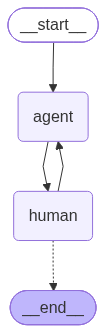

In [7]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
input = {
    "messages": [HumanMessage(content="Hi")]
}

output = graph.invoke(input)
output

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='01be4f15-fb48-4337-85b5-e2c6041f45d7'),
  AIMessage(content='Hi there! How can I help you today?', additional_kwargs={}, response_metadata={}, name='assistant', id='0780471e-ad80-40ab-9ce3-b3ff1fd61450', tool_calls=[], invalid_tool_calls=[])],
 '__interrupt__': [Interrupt(value='Please enter your input: ', id='06513886ee2fae540ed2012d541bb6c1')]}

In [11]:
output['messages']

[HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='01be4f15-fb48-4337-85b5-e2c6041f45d7'),
 AIMessage(content='Hi there! How can I help you today?', additional_kwargs={}, response_metadata={}, name='assistant', id='0780471e-ad80-40ab-9ce3-b3ff1fd61450', tool_calls=[], invalid_tool_calls=[])]